In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('compact.csv')
df['Day'] = pd.to_datetime(df['Day'])
df = df.sort_values(by=['Entity', 'Day'])

# 3. For cumulative data, forward-fill missing values per country
# This bridges the gap between weekly excess death reports and daily confirmed death reports
cols_to_fill = ['Central estimate', 'Lower bound, 95% uncertainty interval', 'Upper bound', 'Confirmed COVID-19 deaths (per 100,000)']
df[cols_to_fill] = df.groupby('Entity')[cols_to_fill].ffill()

# 4. Separate individual countries from aggregate regions (like 'World', 'Africa')
countries_df = df[df['Code'].notna()]
regions_df = df[df['Code'].isna()]
print(regions_df.head())

KeyError: 'Day'

In [9]:
print("Date Range:", df['Day'].min().date(), "to", df['Day'].min().date())
print("Number of unique countries:", countries_df['Entity'].nunique())

# View statistics for the numerical columns
print(countries_df[['Central estimate', 'Confirmed COVID-19 deaths (per 100,000)']].describe())

Date Range: 2020-01-01 to 2020-01-01
Number of unique countries: 250
       Central estimate  Confirmed COVID-19 deaths (per 100,000)
count     521546.000000                            549290.000000
mean         206.611589                                95.271569
std          201.845196                               120.283673
min         -286.298000                                 0.000000
25%           45.585639                                 4.471972
50%          168.519880                                40.487377
75%          313.241180                               154.284840
max         1096.093000                               660.385740


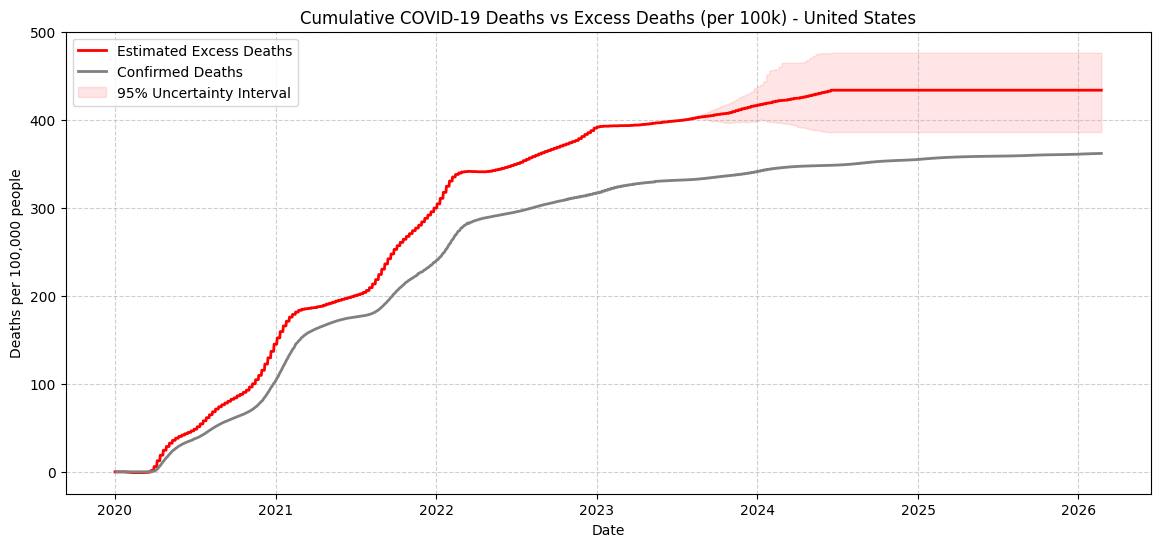

In [16]:
plt.figure(figsize=(14, 6))

# Let's look at a specific country, e.g., the United States
usa_data = countries_df[countries_df['Entity'] == 'United States']

plt.plot(usa_data['Day'], usa_data['Central estimate'], label='Estimated Excess Deaths', color='red', linewidth=2)
plt.plot(usa_data['Day'], usa_data['Confirmed COVID-19 deaths (per 100,000)'], label='Confirmed Deaths', color='grey', linewidth=2)

# Adding the uncertainty interval as a shaded region
plt.fill_between(usa_data['Day'], 
                 usa_data['Lower bound, 95% uncertainty interval'], 
                 usa_data['Upper bound'], 
                 color='red', alpha=0.1, label='95% Uncertainty Interval')

plt.title('Cumulative COVID-19 Deaths vs Excess Deaths (per 100k) - United States')
plt.xlabel('Date')
plt.ylabel('Deaths per 100,000 people')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

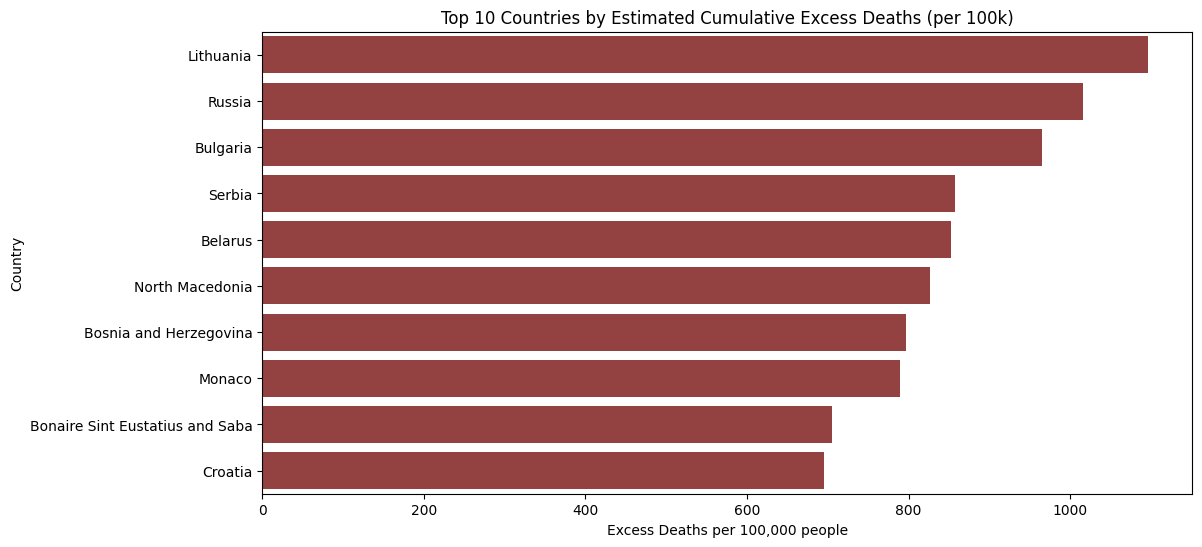

In [17]:
# Get the most recent data point for each country
latest_data = countries_df.groupby('Entity').tail(1).copy()

# Sort to find the top 10 highest excess mortality rates
top_10_excess = latest_data.sort_values(by='Central estimate', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_excess, x='Central estimate', y='Entity', color='darkred', alpha=0.8)
plt.title('Top 10 Countries by Estimated Cumulative Excess Deaths (per 100k)')
plt.xlabel('Excess Deaths per 100,000 people')
plt.ylabel('Country')
plt.show()

In [18]:
latest_data['Undercount_Gap'] = latest_data['Central estimate'] - latest_data['Confirmed COVID-19 deaths (per 100,000)']

# Top 10 countries where official deaths significantly undercount excess deaths
top_undercounts = latest_data.sort_values(by='Undercount_Gap', ascending=False).head(10)

print("Countries with the largest gap between excess and confirmed deaths:")
print(top_undercounts[['Entity', 'Undercount_Gap', 'Central estimate', 'Confirmed COVID-19 deaths (per 100,000)']])

Countries with the largest gap between excess and confirmed deaths:
                                 Entity  Undercount_Gap  Central estimate  \
49342                           Belarus      774.746430         852.34170   
283079                        Lithuania      743.829200        1096.09300   
411159                           Russia      738.266150        1015.97620   
323685                           Monaco      617.794830         789.81024   
442560                           Serbia      591.058770         856.94640   
65043   Bonaire Sint Eustatius and Saba      561.806510         704.89300   
44856                        Bangladesh      500.881940         518.31620   
402187                      Puerto Rico      499.666660         682.88330   
85230                          Cambodia      480.722705         498.48837   
119109                             Cuba      479.835835         556.96185   

        Confirmed COVID-19 deaths (per 100,000)  
49342                             